# Notebook 91 — exact peak/weight structure detector search

This notebook learns small Python-only detectors from the oracle overweight subset discovered in notebook 90, using exact Hough peak-family structure rather than broad mass-gap heuristics.

In [1]:
from pathlib import Path
import subprocess
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_peakweight_precision_detector.py'
OUT = ROOT / 'results' / 'notebook91_peakweight_precision_detector'
SCRIPT, OUT

(PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_peakweight_precision_detector.py'),
 PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector'))

In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
print(completed.returncode)

Loading cached localmax entries from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/angle_profile_localmax_entries.pkl
Evaluating notebook 91 detector variant: baseline_current
Evaluating notebook 91 detector variant: oracle_overweight_to_localmax
Evaluating notebook 91 detector variant: nb90_mass10_gap4_reference
Evaluating notebook 91 detector variant: exact_sparse_peakshape
Evaluating notebook 91 detector variant: exact_balanced_peakshape
# Notebook 91 — exact peak/weight structure detector search

This notebook stays in notebook-only territory: it uses the oracle overweight subset from notebook 90 only as a label,
then searches for small Python-only detectors built from exact Hough peak-family structure around the weighted-median crossing.

## Auto-selected rules

- Sparse high-precision rule: `mass_below_10deg >= 0.3 and best_upper_share <= 0.1`
- Broader exact-structure rule: `mass_below_10deg >= 0.18 and gap_to_lower_deg >= 6 and top_family_an

In [3]:
display(Markdown((OUT / 'notebook91_summary.md').read_text()))

# Notebook 91 — exact peak/weight structure detector search

This notebook stays in notebook-only territory: it uses the oracle overweight subset from notebook 90 only as a label,
then searches for small Python-only detectors built from exact Hough peak-family structure around the weighted-median crossing.

## Auto-selected rules

- Sparse high-precision rule: `mass_below_10deg >= 0.3 and best_upper_share <= 0.1`
- Broader exact-structure rule: `mass_below_10deg >= 0.18 and gap_to_lower_deg >= 6 and top_family_angle_offset <= -6`

## Key findings

- Sparse rule precision/recall: 0.778 / 0.055 on 9 flagged frames.
- Broader rule precision/recall: 0.364 / 0.062 on 22 flagged frames.
- Best downstream FL RMSE among replayed variants is `nb90_mass10_gap4_reference` at 1.2569 mm versus baseline 2.0116 mm.

## Interpretation

- If the sparse rule helps, then a very pure but low-recall detector may already be enough to improve a few pathological segments.
- If the broader exact-structure rule still underperforms the notebook 90 broad heuristic, then detector purity alone is not the full story and we still need a better coverage mechanism.
- The exact-family features tell us whether the overweight frames are defined by weak upper competitors, large lower-side gaps, or a lower family that remains structurally dominant even when the weighted median lands higher.

- Feature table CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/peakweight_feature_table.csv`
- Candidate rule frontier CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/candidate_rule_frontier.csv`
- Selected rules JSON: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/selected_rules.json`
- Raw metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_raw_metrics.csv`
- Persistence metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_persistence_metrics.csv`
- Downstream metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_downstream_metrics.csv`
- Detector stats CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_stats.csv`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_variant_summary.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/detector_per_frame.csv`
- Frontier plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/peakweight_detector_frontier.png`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook91_peakweight_precision_detector/peakweight_detector_traces.png`


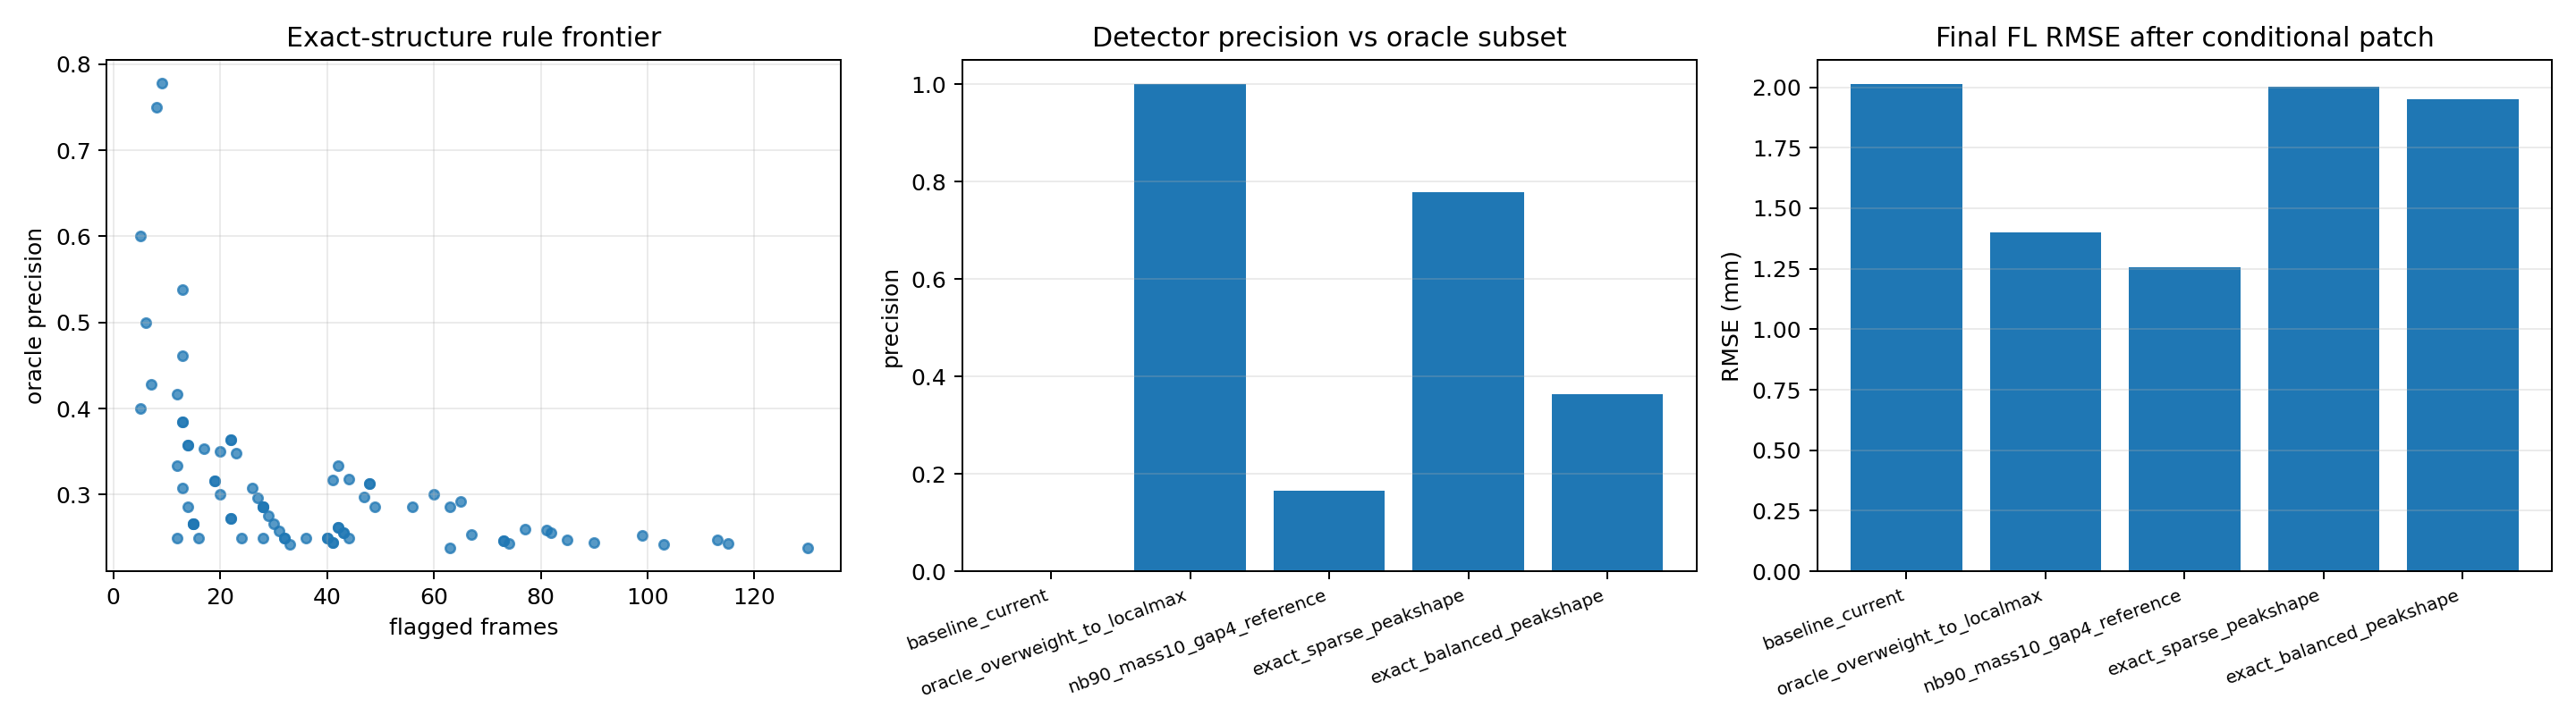

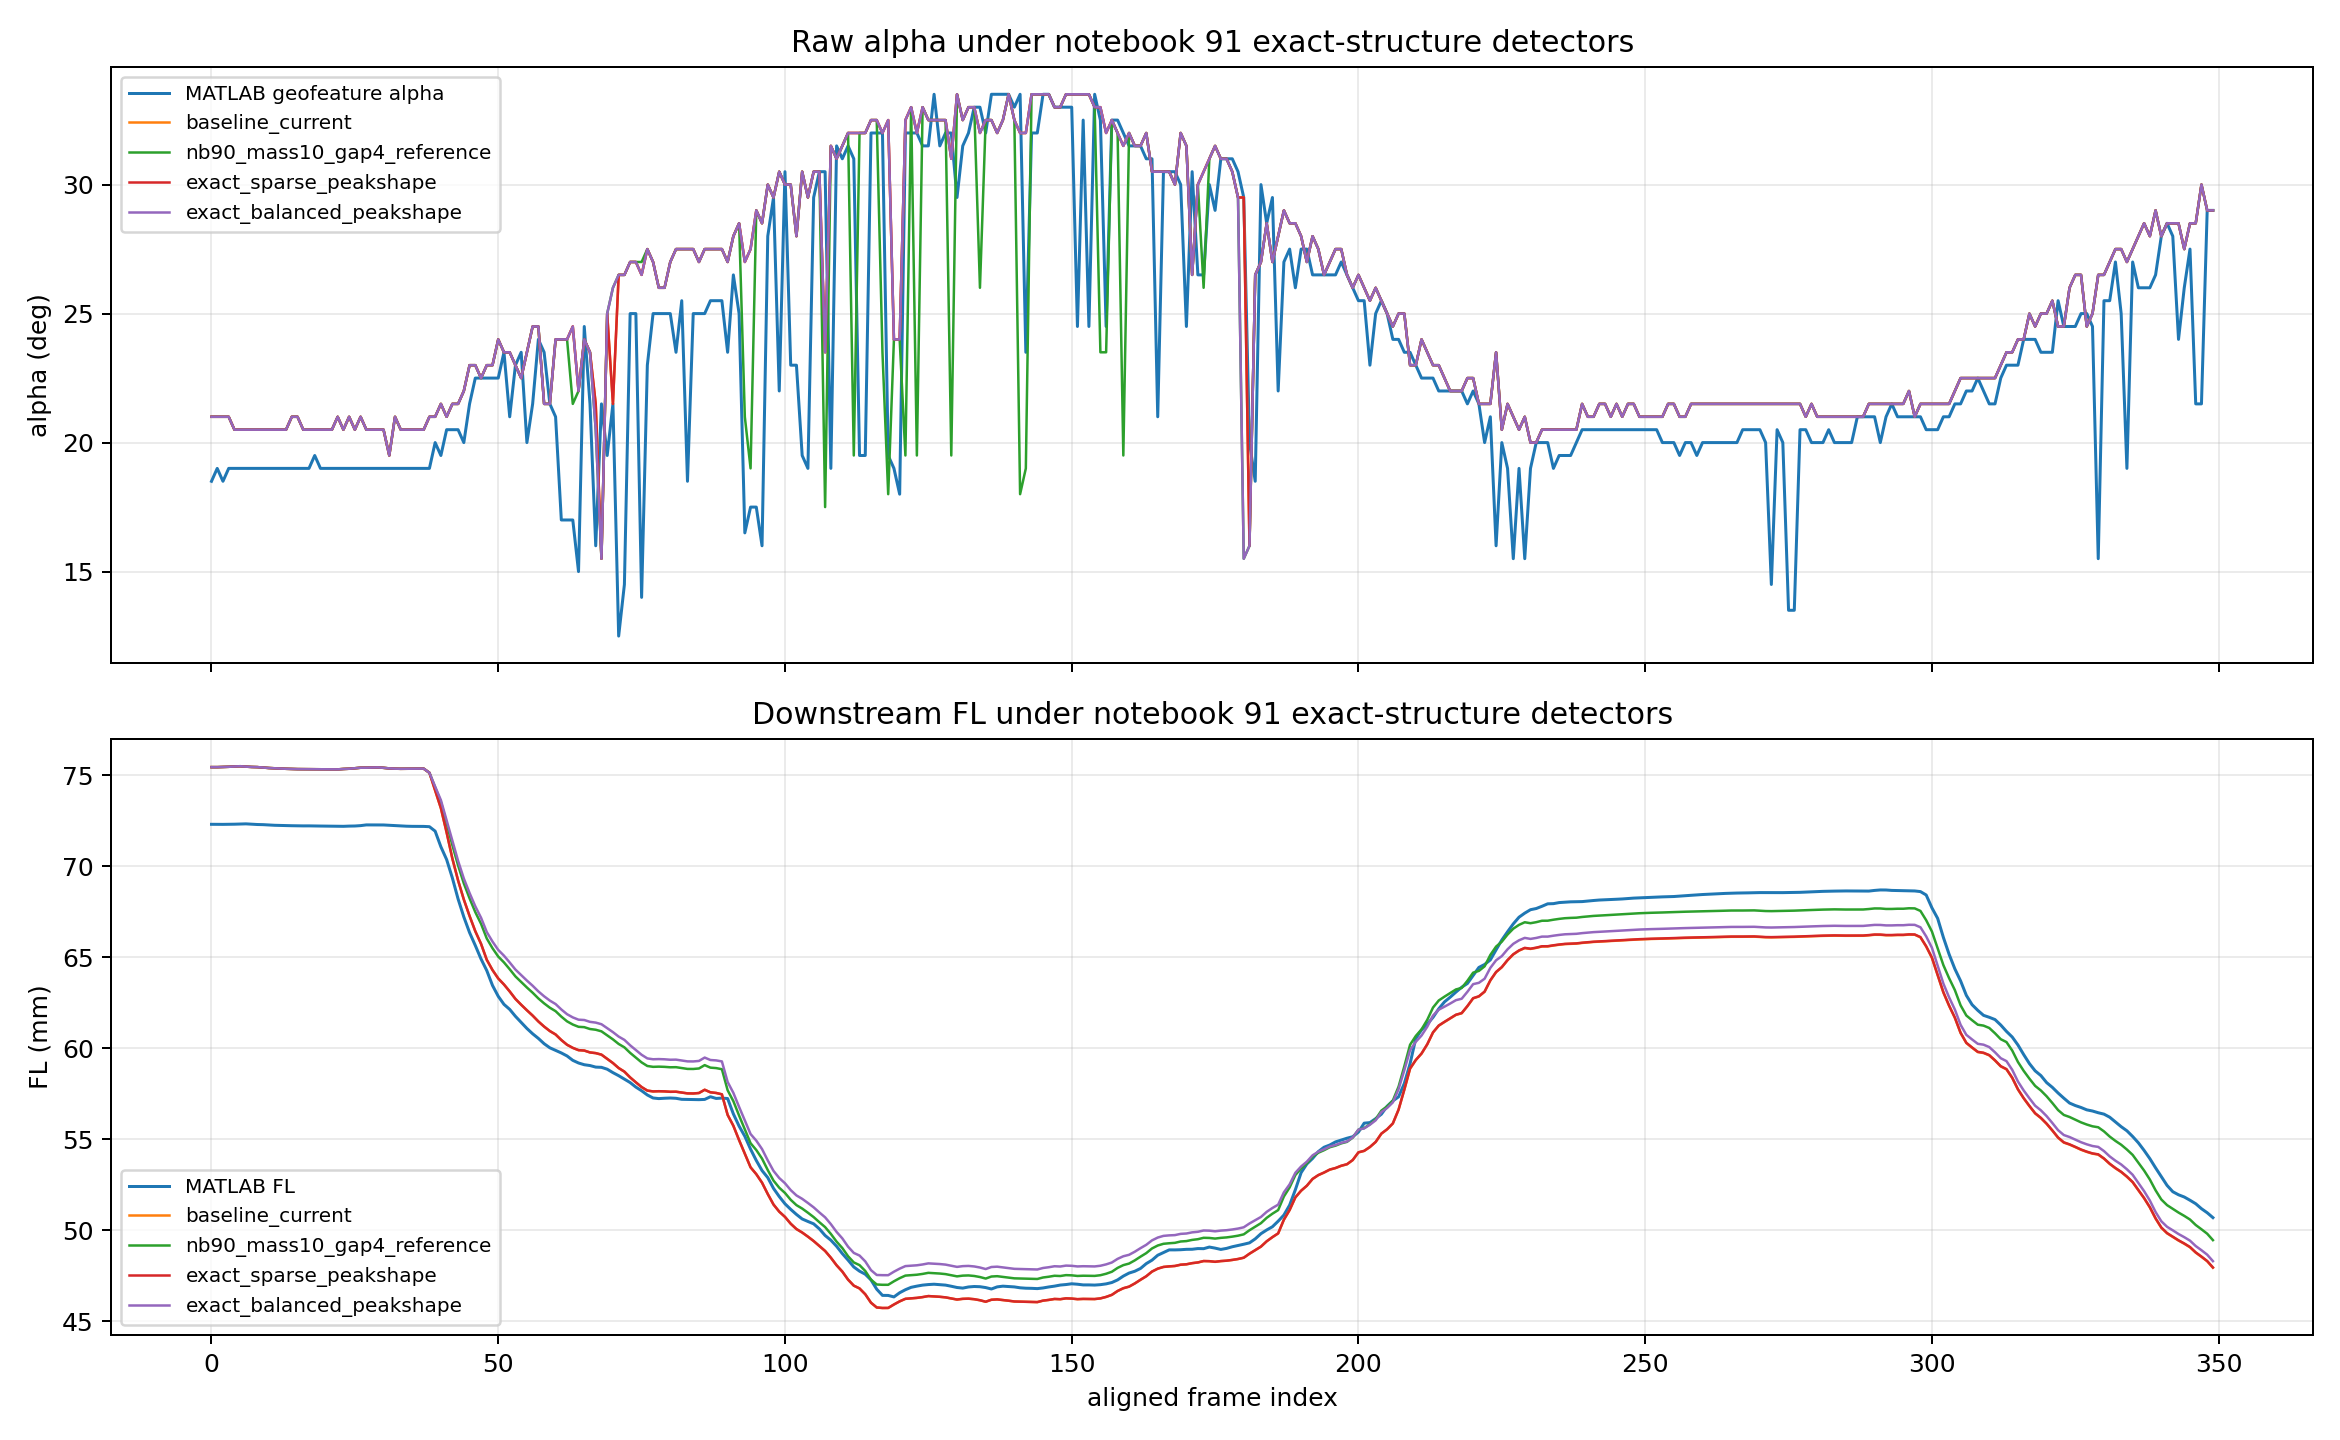

In [4]:
display(Image(filename=str(OUT / 'peakweight_detector_frontier.png')))
display(Image(filename=str(OUT / 'peakweight_detector_traces.png')))